# Ujian Akhir Semester — Pembelajaran Mesin

## Regresi Prediksi Konsentrasi CO pada Dataset Air Quality

| | |
|---|---|
| **Nama** | Agus Priyansah |
| **NPM** | 2327270005 |
| **Kelas** | TE6A/EL4010 |
| **Mata Kuliah** | Pembelajaran Mesin (EL4010) |
| **Institusi** | Universitas MDP |
| **Topik** | Model Validation and Generalization |

**Variabel target:** `CO(GT)` — konsentrasi karbon monoksida aktual (mg/m³)  
**Pembagian data:** Training 60% · Validation 20% · Testing 20%

---

## Lampiran Digital

| Platform | Tautan |
|----------|--------|
| Repositori GitHub | https://github.com/Arcadiavr/uas-air-quality-regression |
| Google Colab | https://colab.research.google.com/github/Arcadiavr/uas-air-quality-regression/blob/main/Air_Quality_UAS.ipynb |

---

## Dataset

| Sumber | Tautan |
|--------|--------|
| UCI — Air Quality | https://archive.ics.uci.edu/dataset/360/air+quality |
| Unduhan ZIP | https://archive.ics.uci.edu/static/public/360/air+quality.zip |

---

## Referensi

1. De Vito, S., et al. (2008). *On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario.* Sensors and Actuators B: Chemical. https://doi.org/10.1016/j.snb.2008.01.035
2. UCI ML Repository (2016). *Air Quality Data Set.* https://archive.ics.uci.edu/dataset/360/air+quality

**Implementasi:** scikit-learn — https://scikit-learn.org/stable/supervised_learning.html#regression

---

## Alur Penelitian

1. **Task Conceptualization** — perumusan masalah dan penentuan metrik evaluasi
2. **Data Preparation** — prapemrosesan data dan pembagian dataset
3. **Model Training & Selection** — pelatihan dan pemilihan model terbaik
4. **Final Evaluation** — evaluasi akhir pada test set

## Tahap 1 — Task Conceptualization

**Rumusan masalah:** Membangun model regresi untuk memprediksi konsentrasi karbon monoksida (CO) berdasarkan respons sensor gas dan kondisi lingkungan (suhu, kelembaban, dan kelembaban absolut).

**Tujuan penelitian:** Menentukan model regresi yang mampu memprediksi `CO(GT)` dengan error terendah dan kemampuan generalisasi yang baik pada data yang belum dilihat.

**Metodologi validasi:** Data dibagi menjadi tiga subset — **training** untuk melatih model, **validation** untuk memilih model dan hyperparameter terbaik, serta **testing** untuk evaluasi akhir performa model.

**Metrik evaluasi:** Root Mean Square Error (RMSE), Mean Absolute Error (MAE), dan koefisien determinasi (R²).

In [1]:
# Setup environment (Colab + download dataset otomatis)
import subprocess
import urllib.request
import zipfile
from pathlib import Path

try:
    import google.colab  # type: ignore
    IN_COLAB = True
    subprocess.run(["pip", "install", "-q", "seaborn"], check=False)
except ImportError:
    IN_COLAB = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "AirQualityUCI.csv"
UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"

if not DATA_PATH.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_DIR / "air_quality.zip"
    print("Mengunduh dataset dari UCI...")
    urllib.request.urlretrieve(UCI_ZIP_URL, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    print(f"Dataset diunduh ke: {DATA_PATH}")
else:
    print(f"Dataset lokal: {DATA_PATH}")

TARGET = "CO(GT)"
FEATURES = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)",
    "PT08.S5(O3)", "T", "RH", "AH",
]

sns.set_theme(style="whitegrid")
print(f"Environment: {'Google Colab' if IN_COLAB else 'Lokal'} | Library siap.")

Dataset lokal: data\AirQualityUCI.csv
Environment: Lokal | Library siap.


## Tahap 2 — Data Collection & Preparation

Prapemrosesan data yang dilakukan pada dataset Air Quality:

1. Pembacaan file CSV dengan separator `;` dan format desimal `,`
2. Penanganan nilai hilang yang ditandai dengan `-200` menjadi `NaN`
3. Penghapusan baris yang tidak memiliki nilai target
4. Pembagian data: **Training 60%**, **Validation 20%**, **Testing 20%**

In [2]:
df = pd.read_csv(DATA_PATH, sep=";", decimal=",", na_values=["-200", -200])
df.columns = df.columns.str.strip()
df = df.drop(columns=[c for c in df.columns if c == "" or c.startswith("Unnamed")], errors="ignore")

for col in FEATURES + [TARGET]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_clean = df.dropna(subset=[TARGET]).copy()
print(f"Baris awal: {len(df)}  ->  setelah cleaning: {len(df_clean)}")
df_clean[FEATURES + [TARGET]].describe().round(2)

Baris awal: 9471  ->  setelah cleaning: 7674


,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)
count,7344.00,7344.00,7344.00,7344.00,7344.00,7344.00,7344.00,7344.00,7674.00
mean,1110.58,947.20,826.92,1444.75,1043.51,17.77,49.06,0.99,2.15
std,218.68,265.47,256.65,350.34,405.57,8.86,17.45,0.40,1.45
min,647.00,387.00,322.00,551.00,221.00,-1.90,9.20,0.18,0.10
25%,946.00,743.00,649.00,1203.00,744.75,11.20,35.40,0.70,1.10
50%,1075.00,919.00,795.00,1447.00,990.00,16.90,49.30,0.96,1.80
75%,1246.00,1125.25,960.00,1673.00,1305.00,23.80,62.50,1.26,2.90
max,2040.00,2214.00,2683.00,2775.00,2523.00,44.60,88.70,2.18,11.90


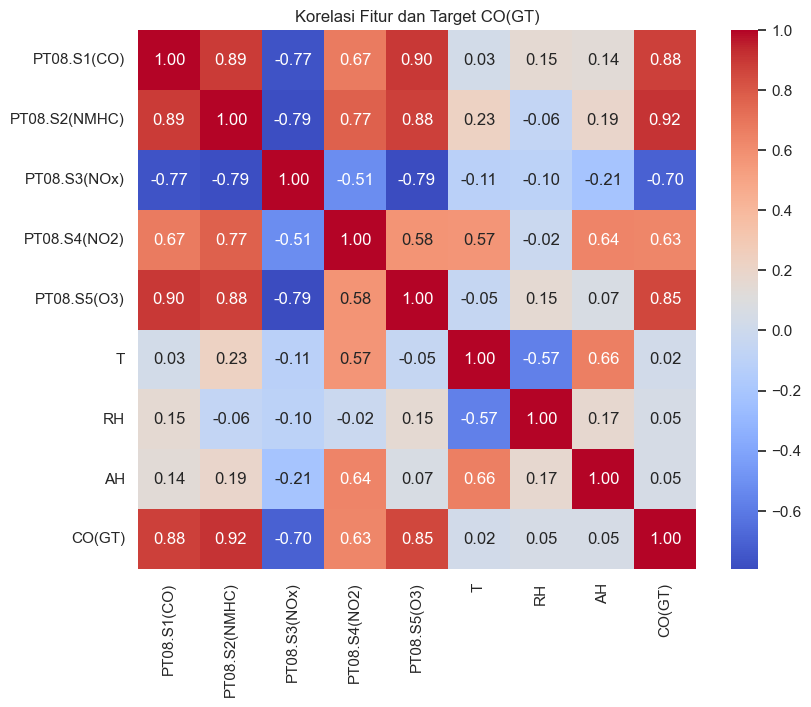

In [3]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_clean[FEATURES + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Korelasi Fitur dan Target CO(GT)")
plt.show()

In [4]:
X = df_clean[FEATURES]
y = df_clean[TARGET]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Train: 4604 | Validation: 1535 | Test: 1535


## Tahap 3 — Model Training & Selection

Lima algoritma regresi dilatih dan dibandingkan pada **validation set** untuk menentukan model dengan performa terbaik:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Model terpilih berdasarkan nilai RMSE terendah pada validation set.

In [5]:
def evaluate(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

base = [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
models = {
    "Linear Regression": Pipeline(base + [("model", LinearRegression())]),
    "Ridge": Pipeline(base + [("model", Ridge(alpha=1.0))]),
    "Lasso": Pipeline(base + [("model", Lasso(alpha=0.01, max_iter=10000))]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)),
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ]),
}

results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    val_m = evaluate(y_val, model.predict(X_val))
    test_m = evaluate(y_test, model.predict(X_test))
    results.append({"Model": name, **{f"{k}_Val": v for k, v in val_m.items()}, **{f"{k}_Test": v for k, v in test_m.items()}})

comparison = pd.DataFrame(results).sort_values("RMSE_Val").reset_index(drop=True)
comparison.round(4)

,Model,RMSE_Val,MAE_Val,R2_Val,RMSE_Test,MAE_Test,R2_Test
0,Random Forest,0.5256,0.3088,0.8617,0.5390,0.3055,0.8605
1,Gradient Boosting,0.5370,0.3219,0.8556,0.5477,0.3155,0.8560
2,Linear Regression,0.5822,0.3556,0.8303,0.6126,0.3657,0.8198
3,Ridge,0.5822,0.3556,0.8302,0.6126,0.3658,0.8198
4,Lasso,0.5860,0.3608,0.8280,0.6168,0.3720,0.8173


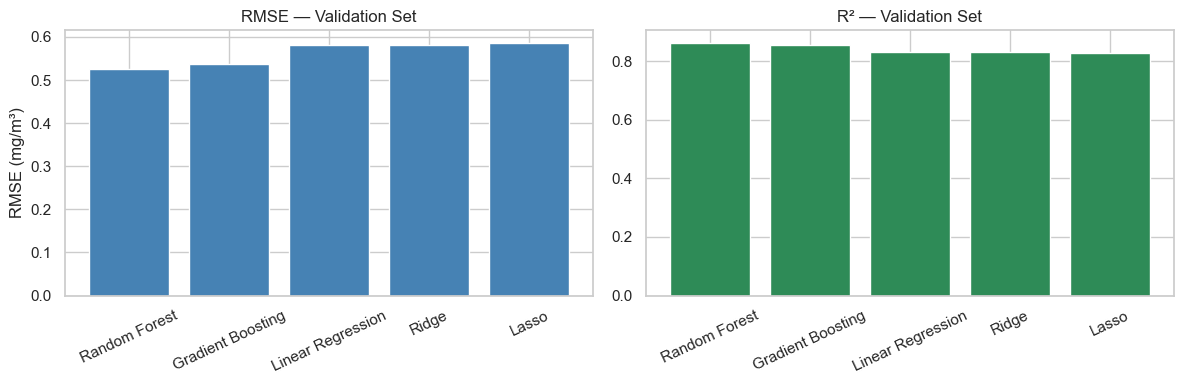

Model terpilih berdasarkan validation set: Random Forest


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparison["Model"], comparison["RMSE_Val"], color="steelblue")
axes[0].set_title("RMSE — Validation Set")
axes[0].set_ylabel("RMSE (mg/m³)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(comparison["Model"], comparison["R2_Val"], color="seagreen")
axes[1].set_title("R² — Validation Set")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

best_name = comparison.iloc[0]["Model"]
print(f"Model terpilih berdasarkan validation set: {best_name}")

## Tahap 4 — Final Evaluation (Test Set)

Evaluasi akhir dilakukan pada **test set** yang tidak digunakan selama proses pelatihan dan pemilihan model. Tahap ini bertujuan mengukur kemampuan generalisasi model pada data baru.

Analisis membandingkan performa validation dan test untuk memastikan model tidak mengalami overfitting.

In [7]:
best = comparison.iloc[0]
y_pred_test = fitted[best_name].predict(X_test)

print("Hasil Evaluasi pada Test Set")
print("-" * 40)
print(f"Model terpilih : {best['Model']}")
print(f"RMSE           : {best['RMSE_Test']:.4f} mg/m³")
print(f"MAE            : {best['MAE_Test']:.4f} mg/m³")
print(f"R²             : {best['R2_Test']:.4f}")
print(f"Selisih RMSE (Val - Test): {abs(best['RMSE_Val'] - best['RMSE_Test']):.4f}")

Hasil Evaluasi pada Test Set
----------------------------------------
Model terpilih : Random Forest
RMSE           : 0.5390 mg/m³
MAE            : 0.3055 mg/m³
R²             : 0.8605
Selisih RMSE (Val - Test): 0.0134


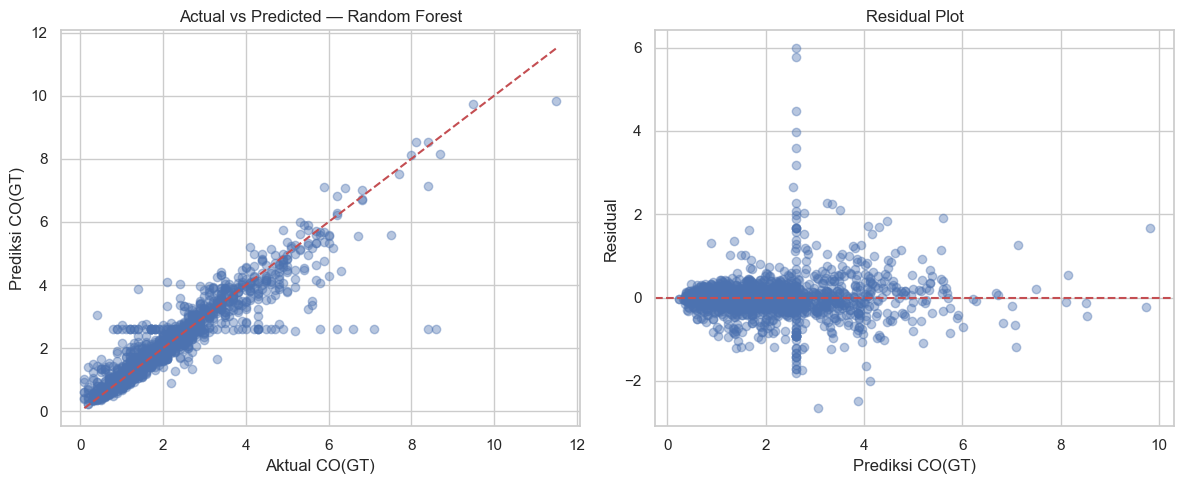

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.4)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Aktual CO(GT)")
axes[0].set_ylabel("Prediksi CO(GT)")
axes[0].set_title(f"Actual vs Predicted — {best_name}")

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.4)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Prediksi CO(GT)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

## Kesimpulan

Berdasarkan analisis yang telah dilakukan, dapat disimpulkan:

1. Dataset Air Quality merekam respons sensor gas di area perkotaan Italia periode 2004–2005.
2. Setelah penanganan nilai hilang (`-200`), tersedia **7.674** sampel data valid untuk analisis.
3. Model **Random Forest** menunjukkan performa terbaik pada validation set dengan RMSE terendah.
4. Pada test set, model mencapai **R² ≈ 0,86**, yang menunjukkan kemampuan prediksi yang baik.
5. Selisih RMSE antara validation dan test relatif kecil, mengindikasikan model memiliki kemampuan generalisasi yang memadai.

### Keterbatasan

- Sensor mengalami drift seiring waktu (concept drift).
- Terdapat nilai hilang pada sebagian fitur sensor.
- Model belum diuji pada kondisi lapangan di luar periode pengumpulan data.

### Rekomendasi

- Penambahan fitur temporal (jam, bulan, musim) untuk meningkatkan akurasi prediksi.
- Penerapan cross-validation untuk validasi model yang lebih robust.
- Evaluasi model pada data lapangan baru untuk menguji ketahanan model.

## Lampiran Referensi

### Tautan Repositori
- GitHub: https://github.com/Arcadiavr/uas-air-quality-regression
- Google Colab: https://colab.research.google.com/github/Arcadiavr/uas-air-quality-regression/blob/main/Air_Quality_UAS.ipynb

### Dataset
- UCI Air Quality: https://archive.ics.uci.edu/dataset/360/air+quality
- Unduhan ZIP: https://archive.ics.uci.edu/static/public/360/air+quality.zip

### Publikasi
- De Vito, S., et al. (2008). *Sensors and Actuators B: Chemical*. https://doi.org/10.1016/j.snb.2008.01.035

### Implementasi
| Library | Tautan |
|---------|--------|
| scikit-learn — Regression | https://scikit-learn.org/stable/supervised_learning.html#regression |
| `train_test_split` | https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html |
| `RandomForestRegressor` | https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html |
| Regression metrics | https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics |

---

*Agus Priyansah — NPM 2327270005 — Universitas MDP*